sin(theta_1(t) - theta_2(t))*cos(theta_1(t) - theta_2(t))*Derivative(theta_1(t), t)**2/(cos(theta_1(t) - theta_2(t))**2 - 2) + sin(theta_1(t) - theta_2(t))*Derivative(theta_2(t), t)**2/(cos(theta_1(t) - theta_2(t))**2 - 2) + 20*sin(theta_1(t))/(cos(theta_1(t) - theta_2(t))**2 - 2) - 10*sin(theta_2(t))*cos(theta_1(t) - theta_2(t))/(cos(theta_1(t) - theta_2(t))**2 - 2)

-sin(theta_1(t) - theta_2(t))*cos(theta_1(t) - theta_2(t))*Derivative(theta_2(t), t)**2/(cos(theta_1(t) - theta_2(t))**2 - 2) - 2*sin(theta_1(t) - theta_2(t))*Derivative(theta_1(t), t)**2/(cos(theta_1(t) - theta_2(t))**2 - 2) - 20*sin(theta_1(t))*cos(theta_1(t) - theta_2(t))/(cos(theta_1(t) - theta_2(t))**2 - 2) + 20*sin(theta_2(t))/(cos(theta_1(t) - theta_2(t))**2 - 2)

Functions successfully lambdified!


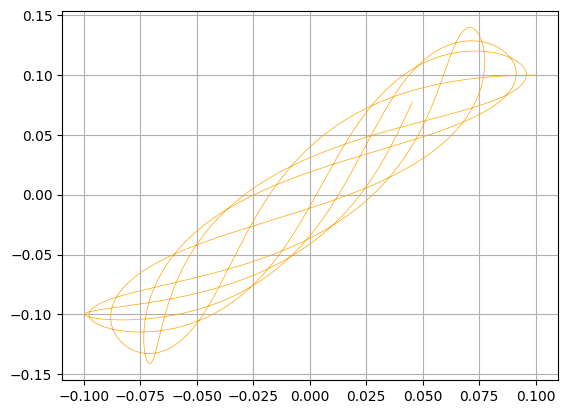

In [50]:
import sympy as sp
from IPython.display import display


# 1. Setup Symbols and Functions
t = sp.symbols("t")
g = 10

# Define angles as functions of time
θ1 = sp.Function("theta_1")(t)
θ2 = sp.Function("theta_2")(t)

# Define velocities as the first derivative of those functions
θ11 = θ1.diff(t)
θ21 = θ2.diff(t)

# 2. Geometry (L1=1, L2=1)
x1 = sp.sin(θ1)
y1 = -sp.cos(θ1)

x2 = x1 + sp.sin(θ2)
y2 = y1 - sp.cos(θ2)

# 3. Kinetic Energy (T)
# Use the direct time derivative of positions
vx1, vy1 = sp.diff(x1, t), sp.diff(y1, t)
vx2, vy2 = sp.diff(x2, t), sp.diff(y2, t)

# m1=1, m2=1. We use (v^2) directly.
v1_sq = vx1**2 + vy1**2
v2_sq = vx2**2 + vy2**2

T = (v1_sq / 2) + (v2_sq / 2)

# 4. Potential Energy (U)
U = g*y1 + g*y2

# 5. Lagrangian (L)
# IMPORTANT: We simplify to collapse sin^2 + cos^2 terms
L = sp.simplify(T - U)

# 6. Euler-Lagrange Equations
# We differentiate L with respect to the velocity functions (θ11, θ21)
eq1 = sp.diff(sp.diff(L, θ11), t) - sp.diff(L, θ1)
eq2 = sp.diff(sp.diff(L, θ21), t) - sp.diff(L, θ2)

# 7. Solve for second derivatives (Accelerations)
θ12 = θ1.diff(t, 2)
θ22 = θ2.diff(t, 2)

sol = sp.solve([eq1, eq2], [θ12, θ22])


# This will render the result as a formal math equation
display(sol[θ12])
display(sol[θ22])


# Define the symbols we want to provide as inputs to the function
# Note: we use the exact objects used in the derivation
inputs = (θ1, θ2, θ11, θ21,t)

# Lambdify the two acceleration solutions
# 'numpy' argument tells SymPy to use np.sin, np.cos, etc.
a1 = sp.lambdify(inputs, sol[θ12], 'numpy')
a2 = sp.lambdify(inputs, sol[θ22], 'numpy')



print("Functions successfully lambdified!")

import matplotlib.pyplot as plt
from scipy.integrate import odeint 
import numpy as np

def acc(state,t):
    θ1,θ2,θ11,θ21=state
    A1=a1(θ1,θ2,θ11,θ21,t)
    A2=a2(θ1,θ2,θ11,θ21,t)
    return (θ11,θ21,A1,A2)

t=np.linspace(0,10,10000)

state0=(0.1,0.1,0,0)

sol=odeint(acc,state0,t)

plt.plot(sol.T[0],sol.T[1],color="orange",lw=0.5)
plt.grid(True)
